# Import Library

In [1]:
!pip install feature_engine


[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: python3 -m pip install --upgrade pip


In [1]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.5/615.5 MB 19.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 21.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 24.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 25.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 31.1 MB/s eta 0:00:0000:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.0
    Uninstalling numpy-2.2.0:
      Successfully uninstalled numpy-2.2.0

[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: python3 -m pip install

In [45]:
!pip install prophet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 50.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 791.2/791.2 kB 35.6 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: python3 -m pip install --upgrade pip


In [1]:
# Load Library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Data Processing
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder
from feature_engine.outliers import Winsorizer


# Modelling
import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report
from tensorflow.keras.layers import Input, concatenate
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, BatchNormalization
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.layers import GRU, Dense, Dropout
from prophet import Prophet
import numpy as np


# Saving
import pickle

2025-02-08 02:15:51.643561: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-08 02:15:51.647549: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-08 02:15:51.656474: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1738980951.670645   15856 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1738980951.674905   15856 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-08 02:15:51.691397: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

# Data Loading

In [2]:
# Path file
file_path = "/workspaces/verbose-space-bassoon/Jakarta Utara/Kelapa Gading/Merged_Data.xlsx"

# Baca file Excel
data = pd.read_excel(file_path)

In [3]:
# Check Data Type

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      365 non-null    datetime64[ns]
 1   PM 10     299 non-null    float64       
 2   PM 2.5    299 non-null    float64       
 3   O2        299 non-null    float64       
 4   CO        299 non-null    float64       
 5   O3        299 non-null    float64       
 6   NO2       299 non-null    float64       
 7   TAVG      365 non-null    object        
 8   RH_AVG    365 non-null    object        
 9   RR        365 non-null    object        
 10  FF_AVG    365 non-null    object        
 11  Location  365 non-null    object        
dtypes: datetime64[ns](1), float64(6), object(5)
memory usage: 34.3+ KB


In [4]:
# List of conversition
cols_to_convert = ["TAVG", "RH_AVG", "RR", "FF_AVG"]

# Conversition to float64
data[cols_to_convert] = data[cols_to_convert].apply(pd.to_numeric, errors="coerce")

In [5]:
# Check Data Type

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      365 non-null    datetime64[ns]
 1   PM 10     299 non-null    float64       
 2   PM 2.5    299 non-null    float64       
 3   O2        299 non-null    float64       
 4   CO        299 non-null    float64       
 5   O3        299 non-null    float64       
 6   NO2       299 non-null    float64       
 7   TAVG      364 non-null    float64       
 8   RH_AVG    364 non-null    float64       
 9   RR        296 non-null    float64       
 10  FF_AVG    364 non-null    float64       
 11  Location  365 non-null    object        
dtypes: datetime64[ns](1), float64(10), object(1)
memory usage: 34.3+ KB


In [6]:
# Show hypothesis analysis about dataset

data.describe()

,Date,PM 10,PM 2.5,O2,CO,O3,NO2,TAVG,RH_AVG,RR,FF_AVG
count,365,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,364.000000,364.000000,296.000000,364.000000
mean,2023-07-02 00:00:00,57.636555,74.862634,35.412440,8.998516,30.721219,22.571311,29.040385,78.392857,665.735473,2.159341
min,2023-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,24.800000,61.000000,0.000000,0.000000
25%,2023-04-02 00:00:00,48.625000,61.572222,21.000000,6.794737,24.073810,17.633333,28.500000,75.000000,0.000000,2.000000
50%,2023-07-02 00:00:00,62.600000,79.555556,32.550000,8.250000,32.263158,21.727273,29.200000,78.000000,0.000000,2.000000
75%,2023-10-01 00:00:00,69.000000,88.975000,53.242647,10.270468,37.527778,26.477273,29.800000,82.000000,4.925000,3.000000
max,2023-12-31 00:00:00,81.900000,107.777778,63.714286,25.272727,51.500000,45.428571,31.300000,96.000000,8888.000000,6.000000
std,NaN,16.211016,19.403142,16.364268,3.306228,9.080132,6.997353,1.086679,5.395851,2333.837905,0.898052


In [7]:
# Check the cardinality of a column

column_cardinality = data.nunique()
column_cardinality

Date        365
PM 10       280
PM 2.5      289
O2          261
CO          229
O3          277
NO2         271
TAVG         54
RH_AVG       31
RR           74
FF_AVG        7
Location      1
dtype: int64

## Missing Value Analysis

In [8]:
# check missing value by isna method

data.isna().sum()

Date         0
PM 10       66
PM 2.5      66
O2          66
CO          66
O3          66
NO2         66
TAVG         1
RH_AVG       1
RR          69
FF_AVG       1
Location     0
dtype: int64

In [9]:
data.rename(columns={'O2': 'SO2'}, inplace=True)

In [10]:
data = data.drop(['Location'], axis=1)

In [11]:
# check outlier by skew method


data.isna().mean()*100

Date       0.000000
PM 10     18.082192
PM 2.5    18.082192
SO2       18.082192
CO        18.082192
O3        18.082192
NO2       18.082192
TAVG       0.273973
RH_AVG     0.273973
RR        18.904110
FF_AVG     0.273973
dtype: float64

## Handling Date

In [12]:
def date_features(df):
    df = df.copy()
    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df["Day"] = df["Date"].dt.day
    df["DayOfWeek"] = df["Date"].dt.dayofweek
    df["OrdinalDate"] = df["Date"].map(pd.Timestamp.toordinal)
    return df.drop(columns=["Date"])  # Hapus kolom asli

data = date_features(data) 

In [13]:
data

,PM 10,PM 2.5,SO2,CO,O3,NO2,TAVG,RH_AVG,RR,FF_AVG,Year,Month,Day,DayOfWeek,OrdinalDate
0,45.823529,60.764706,56.235294,15.117647,20.235294,17.470588,25.9,93.0,38.0,2.0,2023,1,1,6,738521
1,35.789474,45.157895,58.315789,15.052632,22.315789,19.263158,27.2,88.0,134.4,3.0,2023,1,2,0,738522
2,28.833333,33.500000,57.125000,12.958333,21.708333,16.375000,26.7,83.0,0.7,2.0,2023,1,3,1,738523
3,29.947368,42.421053,59.157895,16.894737,19.947368,25.000000,27.0,88.0,3.2,2.0,2023,1,4,2,738524
4,36.454545,53.909091,56.454545,25.272727,22.181818,34.636364,27.5,84.0,31.3,3.0,2023,1,5,3,738525
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,58.714286,83.785714,36.642857,8.428571,27.142857,32.785714,29.4,80.0,0.0,1.0,2023,12,27,2,738881
361,60.388889,79.555556,32.777778,11.222222,31.444444,35.500000,30.4,78.0,0.0,2.0,2023,12,28,3,738882
362,63.421053,86.631579,34.000000,12.789474,32.263158,6.789474,29.8,79.0,0.0,1.0,2023,12,29,4,738883
363,57.400000,83.450000,32.850000,18.550000,30.500000,18.950000,29.7,79.0,8888.0,1.0,2023,12,30,5,738884


# Feature Engine

## Train, Val, and Test Data

In [14]:
# Tentukan jumlah data untuk setiap set
train_size = int(len(data) * 0.6)
val_size = int(len(data) * 0.2)

# Tentukan target yang ingin diprediksi
target_columns = ["SO2", "NO2", "CO", "PM 10", "PM 2.5", "O3"]  # Multivariate forecasting

# Pisahkan fitur (X) dan target (y)
X = data.drop(columns=target_columns)  
y = data[target_columns] 

# Split berdasarkan waktu (tanpa shuffle)
X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_val, y_val = X.iloc[train_size:train_size + val_size], y.iloc[train_size:train_size + val_size]
X_test, y_test = X.iloc[train_size + val_size:], y.iloc[train_size + val_size:]

# Cek hasil
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (219, 9) y_train: (219, 6)
X_val: (73, 9) y_val: (73, 6)
X_test: (73, 9) y_test: (73, 6)


In [22]:
X_train

,TAVG,RH_AVG,RR,FF_AVG,Month,Day,DayOfWeek,OrdinalDate
0,25.9,93.0,38.0,2.0,1,1,6,738521
1,27.2,88.0,134.4,3.0,1,2,0,738522
2,26.7,83.0,0.7,2.0,1,3,1,738523
3,27.0,88.0,3.2,2.0,1,4,2,738524
4,27.5,84.0,31.3,3.0,1,5,3,738525
...,...,...,...,...,...,...,...,...
214,30.0,76.0,NaN,3.0,8,3,3,738735
215,29.5,77.0,0.0,3.0,8,4,4,738736
216,29.3,77.0,NaN,2.0,8,5,5,738737
217,28.9,76.0,0.0,1.0,8,6,6,738738


In [21]:
X_test

,TAVG,RH_AVG,RR,FF_AVG,Month,Day,DayOfWeek,OrdinalDate
292,29.7,78.0,0.0,2.0,10,20,4,738813
293,30.0,75.0,0.0,2.0,10,21,5,738814
294,30.4,74.0,0.0,1.0,10,22,6,738815
295,30.3,72.0,0.0,2.0,10,23,0,738816
296,29.9,74.0,0.0,2.0,10,24,1,738817
...,...,...,...,...,...,...,...,...
360,29.4,80.0,0.0,1.0,12,27,2,738881
361,30.4,78.0,0.0,2.0,12,28,3,738882
362,29.8,79.0,0.0,1.0,12,29,4,738883
363,29.7,79.0,8888.0,1.0,12,30,5,738884


In [15]:
X_train.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)
X_val.reset_index(drop=True, inplace=True)
y_val.reset_index(drop=True, inplace=True)
y_train.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

## Get Numerical and Categorical

In [15]:
X_train

,TAVG,RH_AVG,RR,FF_AVG,Year,Month,Day,DayOfWeek,OrdinalDate
0,25.9,93.0,38.0,2.0,2023,1,1,6,738521
1,27.2,88.0,134.4,3.0,2023,1,2,0,738522
2,26.7,83.0,0.7,2.0,2023,1,3,1,738523
3,27.0,88.0,3.2,2.0,2023,1,4,2,738524
4,27.5,84.0,31.3,3.0,2023,1,5,3,738525
...,...,...,...,...,...,...,...,...,...
214,30.0,76.0,NaN,3.0,2023,8,3,3,738735
215,29.5,77.0,0.0,3.0,2023,8,4,4,738736
216,29.3,77.0,NaN,2.0,2023,8,5,5,738737
217,28.9,76.0,0.0,1.0,2023,8,6,6,738738


In [16]:
# Define Numerical Columns
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()

## Feature Selection

In [17]:
low_variance_cols = X_train.var()[X_train.var() < 1e-5].index.tolist()
print("Kolom dengan variasi rendah:", low_variance_cols)

Kolom dengan variasi rendah: ['Year']


In [18]:
X_train.drop(columns=["Year"], inplace=True)
X_val.drop(columns=["Year"], inplace=True)
X_test.drop(columns=["Year"], inplace=True)

/tmp/ipykernel_15856/1554458973.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train.drop(columns=["Year"], inplace=True)
/tmp/ipykernel_15856/1554458973.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val.drop(columns=["Year"], inplace=True)
/tmp/ipykernel_15856/1554458973.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test.drop(columns=["Year"], inplace=True)


In [19]:
# Outlier

outlier_moderate = ["TAVG", "RH_AVG", "FF_AVG"]  # < 5% Outlier
date_columns = ["Month", "Day", "DayOfWeek", "OrdinalDate"]  # Fitur waktu yang dipertahankan

### Handling Missing Value

In [20]:
# 1️⃣ Cek apakah ada NaN di target (y)
print("Cek NaN di y_train:", np.isnan(y_train).sum())
print("Cek NaN di y_val:", np.isnan(y_val).sum())
print("Cek NaN di y_test:", np.isnan(y_test).sum())

# 2️⃣ Handle NaN di y_train, y_val, y_test
y_train = np.nan_to_num(y_train, nan=np.nanmean(y_train))
y_val = np.nan_to_num(y_val, nan=np.nanmean(y_val))
y_test = np.nan_to_num(y_test, nan=np.nanmean(y_test))

# 3️⃣ Cek ulang apakah masih ada NaN
print("Cek ulang NaN di y_train:", np.isnan(y_train).sum())
print("Cek ulang NaN di y_val:", np.isnan(y_val).sum())
print("Cek ulang NaN di y_test:", np.isnan(y_test).sum())


Cek NaN di y_train: SO2       64
NO2       64
CO        64
PM 10     64
PM 2.5    64
O3        64
dtype: int64
Cek NaN di y_val: SO2       1
NO2       1
CO        1
PM 10     1
PM 2.5    1
O3        1
dtype: int64
Cek NaN di y_test: SO2       1
NO2       1
CO        1
PM 10     1
PM 2.5    1
O3        1
dtype: int64
Cek ulang NaN di y_train: 0
Cek ulang NaN di y_val: 0
Cek ulang NaN di y_test: 0


# Pipeline

In [23]:
clip_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

date_pipeline = Pipeline([
    ('scaler', MinMaxScaler())
])

# Final Pipeline
final_pipeline = ColumnTransformer(
    transformers=[
        ('clip', clip_pipeline, outlier_moderate),
        ('date', date_pipeline, date_columns)  # Tangani tanggal secara terpisah
    ]
)

In [24]:
# application pipeline data processing

X_train = final_pipeline.fit_transform(X_train)
X_val = final_pipeline.fit_transform(X_val)
X_test = final_pipeline.fit_transform(X_test)

In [25]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (219, 7)
X_val shape: (73, 7)
X_test shape: (73, 7)


In [26]:
# Input Data Pipeline

train_pipe = tf.data.Dataset.from_tensor_slices((X_train,y_train)).batch(32).prefetch(tf.data.AUTOTUNE)
test_pipe = tf.data.Dataset.from_tensor_slices((X_test,y_test)).batch(32)
val_pipe = tf.data.Dataset.from_tensor_slices((X_val,y_val)).batch(32)

2025-02-08 02:18:19.366939: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


# Modeling

## Hybrid ES-RNN

### Model Definition

In [27]:
# 1️⃣ Exponential Smoothing (ES) untuk Menangkap Tren & Musiman
def apply_exponential_smoothing(series, trend="add", seasonal="add", seasonal_periods=12):
    model_es = ExponentialSmoothing(series, trend=trend, seasonal=seasonal, seasonal_periods=seasonal_periods)
    fitted_model = model_es.fit()
    return fitted_model.fittedvalues, fitted_model.forecast(steps=30)

# 2️⃣ Membangun Model LSTM untuk Menangkap Pola Non-Linear
model_es_rnn = Sequential([
    LSTM(64, return_sequences=True, input_shape=(30, 1)),  # 30 timesteps, 1 feature
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(6)  # Output satu nilai (regresi time series)
])

# 3️⃣ Kompilasi Model
model_es_rnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="mse")

# 4️⃣ Tampilkan Struktur Model
model_es_rnn.summary()

/home/codespace/.python/current/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,510 (115.27 KB)

 Trainable params: 29,510 (115.27 KB)

 Non-trainable params: 0 (0.00 B)

### Model Training

In [28]:
# Define erlystopping

early_stopping = EarlyStopping(
    monitor='loss',
    patience=10,
    mode='auto',
    baseline=None,
    restore_best_weights=True,
)

In [29]:
# Training Model


history_hybrid = model_es_rnn.fit(train_pipe,
                                   epochs=100,
                                   validation_data=(val_pipe),
                                   batch_size=30,
                                   callbacks=[early_stopping])

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 1419.2090 - val_loss: 2589.2683
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1411.4205 - val_loss: 2576.1318
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1398.0254 - val_loss: 2547.0774
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1365.8656 - val_loss: 2479.9983
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1301.7527 - val_loss: 2386.5771
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1231.6923 - val_loss: 2319.6995
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1182.2668 - val_loss: 2280.3962
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1156.8979 - val_loss: 2251.9282
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1135.4565 - val_loss: 2227.1753
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1118.3042 - val_loss: 2204.2480
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1102.4034 - val_loss: 2182.5891
Epoch 12/100
7/7 ━

### Model Evaluation

In [ ]:
# 1️⃣ Pastikan jumlah y_pred sesuai dengan y_test
y_pred = model_es_rnn.predict(X_test)

# 2️⃣ Hitung Metrik Evaluasi
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test - y_pred) / np.maximum(y_test, 1e-10))) * 100  

# 3️⃣ Tampilkan Hasil Evaluasi
print(f"🔹 Evaluasi Model Hybrid ES-RNN:")
print(f"   ✅ MAE  : {mae:.4f}")
print(f"   ✅ MSE  : {mse:.4f}")
print(f"   ✅ RMSE : {rmse:.4f}")
print(f"   ✅ MAPE : {mape:.4f}%")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
🔹 Evaluasi Model Hybrid ES-RNN:
   ✅ MAE  : 21.5240
   ✅ MSE  : 864.8761
   ✅ RMSE : 29.4088
   ✅ MAPE : 341790351757.4948%


## LSTM

### Model Definition

In [31]:
# Clear Session

seed = 20
tf.keras.backend.clear_session()
np.random.seed(seed)
tf.random.set_seed(seed)

In [32]:
# 1. Membuat model LSTM
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(10, 1)),  # 10 timesteps, 1 feature
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(6)  # Output 1 nilai (regresi time series)
])

# 2. Kompilasi model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# 3. Tampilkan arsitektur model
model.summary()


/home/codespace/.python/current/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,510 (115.27 KB)

 Trainable params: 29,510 (115.27 KB)

 Non-trainable params: 0 (0.00 B)

### Model Traingin

In [33]:
# Define erlystopping

early_stopping = EarlyStopping(
    monitor='loss',
    patience=10,
    mode='auto',
    baseline=None,
    restore_best_weights=True,
)

In [37]:
# Training Model


history_seq = model.fit(train_pipe,
                                   epochs=100,
                                   validation_data=(val_pipe),
                                   batch_size=30,
                                   callbacks=[early_stopping])

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 673.6426 - val_loss: 1578.0449
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 664.9572 - val_loss: 1566.4467
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 661.8603 - val_loss: 1554.9723
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 663.3950 - val_loss: 1543.6411
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 650.3067 - val_loss: 1532.4525
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 642.9370 - val_loss: 1521.3591
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 638.1840 - val_loss: 1510.3822
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 636.7250 - val_loss: 1499.5229
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 627.8551 - val_loss: 1488.7832
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 619.2473 - val_loss: 1478.1783
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 614.5317 - val_loss: 1467.6843
Epoch 12/100
7/7 ━━━━━━━━━━

### Model Evaluation

In [79]:
# Melakukan prediksi pada test set
y_pred = model.predict(X_test)

# Hitung MAE, MSE, RMSE
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Tampilkan hasil evaluasi
print(f"Mean Absolute Error (MAE) LSTM: {mae:.4f}")
print(f"Mean Squared Error (MSE) LSTM: {mse:.4f}")
print(f"Root Mean Squared Error (RMSE) LSTM: {rmse:.4f}")

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Mean Absolute Error (MAE) LSTM: 18.0396
Mean Squared Error (MSE) LSTM: 629.3113
Root Mean Squared Error (RMSE) LSTM: 25.0861


## GRU

### Model Definition

In [40]:
# Membangun Model GRU
model_gru = Sequential([
    GRU(64, return_sequences=True, input_shape=(10, 1)),  # 10 timesteps, 1 feature
    Dropout(0.2),
    GRU(32),
    Dropout(0.2),
    Dense(6)
])

# Kompilasi Model
model_gru.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Tampilkan Struktur Model
model_gru.summary()

/home/codespace/.python/current/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 10, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,470 (87.77 KB)

 Trainable params: 22,470 (87.77 KB)

 Non-trainable params: 0 (0.00 B)

### Model Training

In [41]:
# Define erlystopping

early_stopping = EarlyStopping(
    monitor='loss',
    patience=10,
    mode='auto',
    baseline=None,
    restore_best_weights=True,
)

In [42]:
# Training Model

history_gru = model_gru.fit(train_pipe,
                                   epochs=100,
                                   validation_data=(val_pipe),
                                   batch_size=30,
                                   callbacks=[early_stopping])

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 1415.8424 - val_loss: 2578.0315
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1402.5432 - val_loss: 2551.8857
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1379.1970 - val_loss: 2499.4277
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1332.9817 - val_loss: 2395.8455
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1254.2455 - val_loss: 2290.7180
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1189.2686 - val_loss: 2247.8025
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1163.9510 - val_loss: 2221.7795
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1141.3862 - val_loss: 2198.6362
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1124.0271 - val_loss: 2176.6809
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1111.2745 - val_loss: 2155.7100
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1095.3337 - val_loss: 2135.5176
Epoch 12/100
7/7

### Model Evaluation

In [80]:
# Melakukan prediksi pada test set
y_pred_gru = model_gru.predict(X_test)

# Hitung MAE, MSE, RMSE
mae_gru = mean_absolute_error(y_test, y_pred_gru)
mse_gru = mean_squared_error(y_test, y_pred_gru)
rmse_gru = np.sqrt(mse)

# Tampilkan hasil evaluasi
print(f"Mean Absolute Error (MAE) GRU: {mae_gru:.4f}")
print(f"Mean Squared Error (MSE) GRU: {mse_gru:.4f}")
print(f"Root Mean Squared Error (RMSE) GRU: {rmse_gru:.4f}")

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Mean Absolute Error (MAE) GRU: 21.1556
Mean Squared Error (MSE) GRU: 839.9193
Root Mean Squared Error (RMSE) GRU: 25.0861


## Prophet

### Data Pre-Processing

In [54]:
df_prophet = data.copy()

In [55]:
df_prophet

,PM 10,PM 2.5,SO2,CO,O3,NO2,TAVG,RH_AVG,RR,FF_AVG,Year,Month,Day,DayOfWeek,OrdinalDate
0,45.823529,60.764706,56.235294,15.117647,20.235294,17.470588,25.9,93.0,38.0,2.0,2023,1,1,6,738521
1,35.789474,45.157895,58.315789,15.052632,22.315789,19.263158,27.2,88.0,134.4,3.0,2023,1,2,0,738522
2,28.833333,33.500000,57.125000,12.958333,21.708333,16.375000,26.7,83.0,0.7,2.0,2023,1,3,1,738523
3,29.947368,42.421053,59.157895,16.894737,19.947368,25.000000,27.0,88.0,3.2,2.0,2023,1,4,2,738524
4,36.454545,53.909091,56.454545,25.272727,22.181818,34.636364,27.5,84.0,31.3,3.0,2023,1,5,3,738525
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,58.714286,83.785714,36.642857,8.428571,27.142857,32.785714,29.4,80.0,0.0,1.0,2023,12,27,2,738881
361,60.388889,79.555556,32.777778,11.222222,31.444444,35.500000,30.4,78.0,0.0,2.0,2023,12,28,3,738882
362,63.421053,86.631579,34.000000,12.789474,32.263158,6.789474,29.8,79.0,0.0,1.0,2023,12,29,4,738883
363,57.400000,83.450000,32.850000,18.550000,30.500000,18.950000,29.7,79.0,8888.0,1.0,2023,12,30,5,738884


In [56]:
df_prophet["ds"] = pd.to_datetime(df_prophet[["Year", "Month", "Day"]])

In [57]:
df_prophet = df_prophet.drop(["Year", "Month", "Day", "OrdinalDate", "DayOfWeek"], axis=1)

In [58]:
df_prophet

,PM 10,PM 2.5,SO2,CO,O3,NO2,TAVG,RH_AVG,RR,FF_AVG,ds
0,45.823529,60.764706,56.235294,15.117647,20.235294,17.470588,25.9,93.0,38.0,2.0,2023-01-01
1,35.789474,45.157895,58.315789,15.052632,22.315789,19.263158,27.2,88.0,134.4,3.0,2023-01-02
2,28.833333,33.500000,57.125000,12.958333,21.708333,16.375000,26.7,83.0,0.7,2.0,2023-01-03
3,29.947368,42.421053,59.157895,16.894737,19.947368,25.000000,27.0,88.0,3.2,2.0,2023-01-04
4,36.454545,53.909091,56.454545,25.272727,22.181818,34.636364,27.5,84.0,31.3,3.0,2023-01-05
...,...,...,...,...,...,...,...,...,...,...,...
360,58.714286,83.785714,36.642857,8.428571,27.142857,32.785714,29.4,80.0,0.0,1.0,2023-12-27
361,60.388889,79.555556,32.777778,11.222222,31.444444,35.500000,30.4,78.0,0.0,2.0,2023-12-28
362,63.421053,86.631579,34.000000,12.789474,32.263158,6.789474,29.8,79.0,0.0,1.0,2023-12-29
363,57.400000,83.450000,32.850000,18.550000,30.500000,18.950000,29.7,79.0,8888.0,1.0,2023-12-30


In [62]:
# 1. Tampilkan jumlah NaN sebelum pemrosesan
print("Jumlah NaN sebelum pemrosesan:\n", df_prophet.isna().sum())

# 2. Isi NaN dengan nilai median dari masing-masing kolom
df_prophet.fillna(df_prophet.median(), inplace=True)

# 3. Tampilkan jumlah NaN setelah pemrosesan
print("Jumlah NaN setelah pemrosesan:\n", df_prophet.isna().sum())

Jumlah NaN sebelum pemrosesan:
 PM 10     66
PM 2.5    66
SO2       66
CO        66
O3        66
NO2       66
TAVG       1
RH_AVG     1
RR        69
FF_AVG     1
ds         0
dtype: int64
Jumlah NaN setelah pemrosesan:
 PM 10     0
PM 2.5    0
SO2       0
CO        0
O3        0
NO2       0
TAVG      0
RH_AVG    0
RR        0
FF_AVG    0
ds        0
dtype: int64


In [64]:
df_prophet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   PM 10   365 non-null    float64       
 1   PM 2.5  365 non-null    float64       
 2   SO2     365 non-null    float64       
 3   CO      365 non-null    float64       
 4   O3      365 non-null    float64       
 5   NO2     365 non-null    float64       
 6   TAVG    365 non-null    float64       
 7   RH_AVG  365 non-null    float64       
 8   RR      365 non-null    float64       
 9   FF_AVG  365 non-null    float64       
 10  ds      365 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(10)
memory usage: 31.5 KB


In [65]:
from feature_engine.outliers import Winsorizer

# 1️⃣ Tentukan variabel numerik yang akan di-Winsorizer (kecuali 'ds')
numerical_cols = df_prophet.columns.drop("ds").tolist()

# 2️⃣ Terapkan Winsorizer dengan metode IQR
winsor = Winsorizer(capping_method='iqr', tail='both', fold=1.5, variables=numerical_cols)

# 3️⃣ Fit dan transform df_prophet (hanya kolom numerik)
df_prophet[numerical_cols] = winsor.fit_transform(df_prophet[numerical_cols])

# 4️⃣ Cek distribusi setelah Winsorizer
print("Distribusi setelah Winsorizer:\n", df_prophet.describe())


Distribusi setelah Winsorizer:
             PM 10      PM 2.5         SO2          CO          O3         NO2  \
count  365.000000  365.000000  365.000000  365.000000  365.000000  365.000000   
mean    59.355775   76.322435   34.894848    8.699388   31.056222   22.353587   
min     34.208333   42.611111    0.000000    2.736842   10.052632    8.107143   
25%     54.350000   69.111111   21.736842    7.000000   26.000000   18.500000   
50%     62.600000   79.555556   32.550000    8.250000   32.263158   21.727273   
75%     67.777778   86.777778   52.350000    9.842105   36.631579   25.428571   
max     81.900000  107.777778   63.714286   14.105263   51.500000   35.821429   
std     12.803771   16.115897   14.847595    2.438276    8.064913    5.910904   

             TAVG      RH_AVG         RR      FF_AVG                   ds  
count  365.000000  365.000000  365.00000  365.000000                  365  
mean    29.060137   78.380822    1.24000    2.153425  2023-07-02 00:00:00  
min     26

In [66]:
df_prophet

,PM 10,PM 2.5,SO2,CO,O3,NO2,TAVG,RH_AVG,RR,FF_AVG,ds
0,45.823529,60.764706,56.235294,14.105263,20.235294,17.470588,26.55,92.5,5.0,2.0,2023-01-01
1,35.789474,45.157895,58.315789,14.105263,22.315789,19.263158,27.20,88.0,5.0,3.0,2023-01-02
2,34.208333,42.611111,57.125000,12.958333,21.708333,16.375000,26.70,83.0,0.7,2.0,2023-01-03
3,34.208333,42.611111,59.157895,14.105263,19.947368,25.000000,27.00,88.0,3.2,2.0,2023-01-04
4,36.454545,53.909091,56.454545,14.105263,22.181818,34.636364,27.50,84.0,5.0,3.0,2023-01-05
...,...,...,...,...,...,...,...,...,...,...,...
360,58.714286,83.785714,36.642857,8.428571,27.142857,32.785714,29.40,80.0,0.0,1.0,2023-12-27
361,60.388889,79.555556,32.777778,11.222222,31.444444,35.500000,30.40,78.0,0.0,2.0,2023-12-28
362,63.421053,86.631579,34.000000,12.789474,32.263158,8.107143,29.80,79.0,0.0,1.0,2023-12-29
363,57.400000,83.450000,32.850000,14.105263,30.500000,18.950000,29.70,79.0,5.0,1.0,2023-12-30


### Model Definition

In [67]:
#  Definisi Model Prophet
model_prophet = Prophet(
    seasonality_mode='additive',   # Bisa 'multiplicative' jika pola musiman non-linear
    yearly_seasonality=True,       # Menangkap pola tahunan
    weekly_seasonality=True,       # Menangkap pola mingguan
    daily_seasonality=False,       # Bisa diaktifkan jika data memiliki variasi harian besar
    interval_width=0.95            # Confidence interval 95%
)

# Tampilkan Struktur Model
print(model_prophet)

### Model Training

In [69]:
# 1️⃣ Daftar target polutan yang ingin diprediksi
target_columns = ["SO2", "NO2", "CO", "PM 10", "PM 2.5", "O3"]

# 2️⃣ Ubah data ke format long
df_long = df_prophet.melt(id_vars=["ds"], value_vars=target_columns, var_name="pollutant", value_name="y")

# 3️⃣ Cek hasil format long
print(df_long.head())

          ds pollutant          y
0 2023-01-01       SO2  56.235294
1 2023-01-02       SO2  58.315789
2 2023-01-03       SO2  57.125000
3 2023-01-04       SO2  59.157895
4 2023-01-05       SO2  56.454545


In [70]:
df_long

,ds,pollutant,y
0,2023-01-01,SO2,56.235294
1,2023-01-02,SO2,58.315789
2,2023-01-03,SO2,57.125000
3,2023-01-04,SO2,59.157895
4,2023-01-05,SO2,56.454545
...,...,...,...
2185,2023-12-27,O3,27.142857
2186,2023-12-28,O3,31.444444
2187,2023-12-29,O3,32.263158
2188,2023-12-30,O3,30.500000


In [71]:
model_prophet.fit(df_long)

11:08:36 - cmdstanpy - INFO - Chain [1] start processing
11:08:37 - cmdstanpy - INFO - Chain [1] done processing


In [72]:
future = model_prophet.make_future_dataframe(periods=30)

In [73]:
forecast = model_prophet.predict(future)

In [74]:
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(10)

,ds,yhat,yhat_lower,yhat_upper
385,2024-01-21,39.357478,-10.862236,85.984856
386,2024-01-22,38.079247,-11.917689,87.228784
387,2024-01-23,38.288230,-9.364714,84.877098
388,2024-01-24,38.412055,-8.789425,81.861966
389,2024-01-25,39.019812,-9.704664,87.721876
390,2024-01-26,38.711657,-9.758619,85.536093
391,2024-01-27,38.196816,-10.909397,87.568444
392,2024-01-28,36.740406,-9.251351,86.866672
393,2024-01-29,35.280210,-12.988129,83.147257
394,2024-01-30,35.328836,-8.393797,87.485093


### Model Evaluation

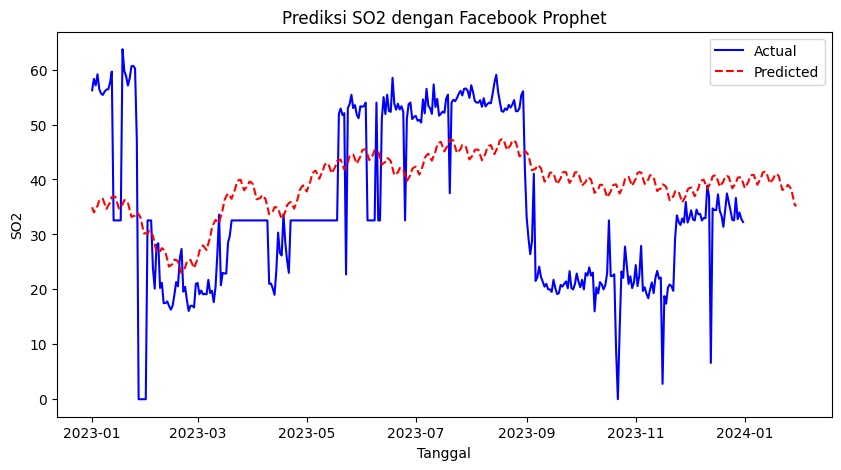

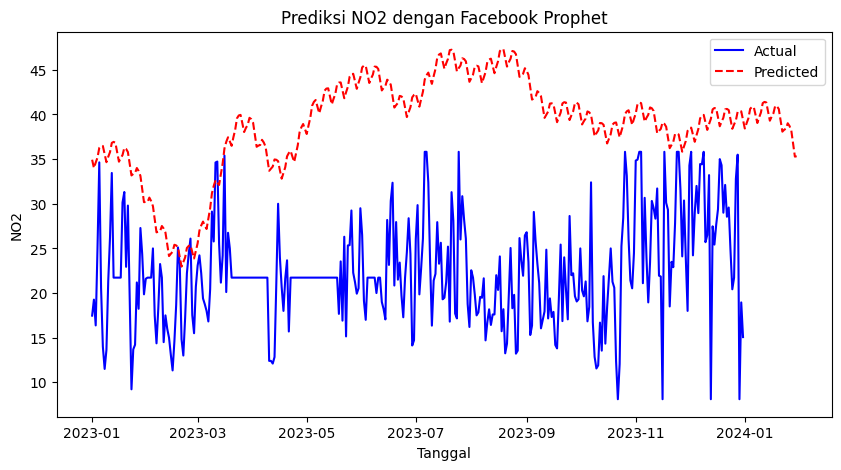

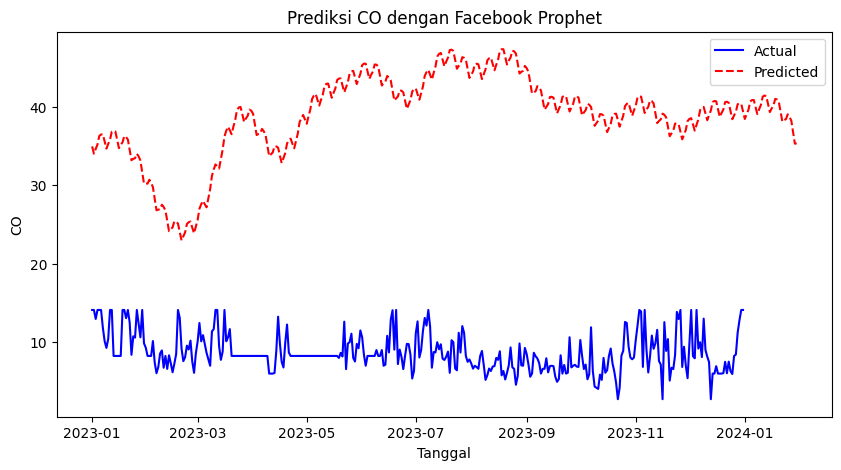

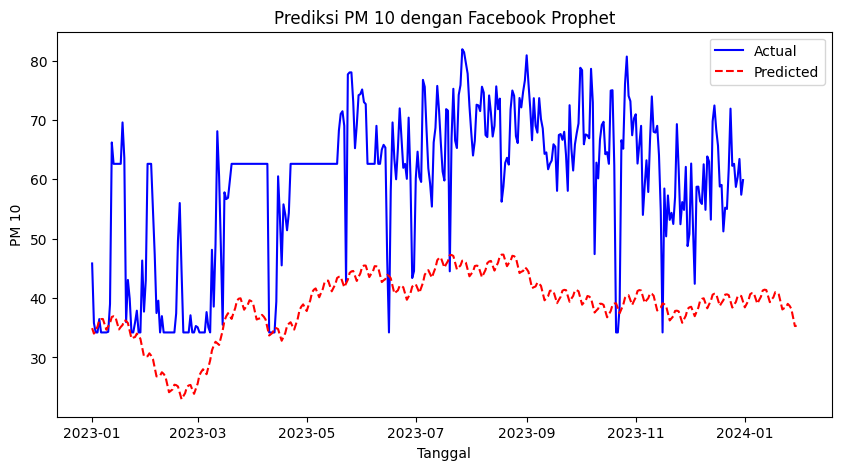

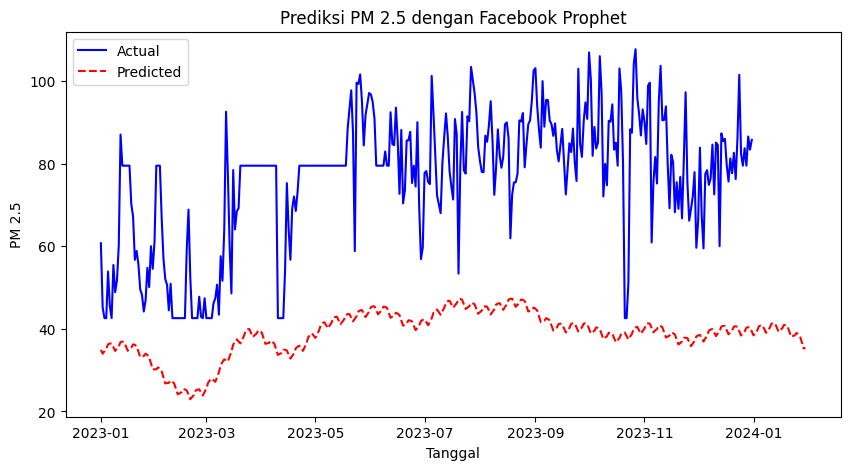

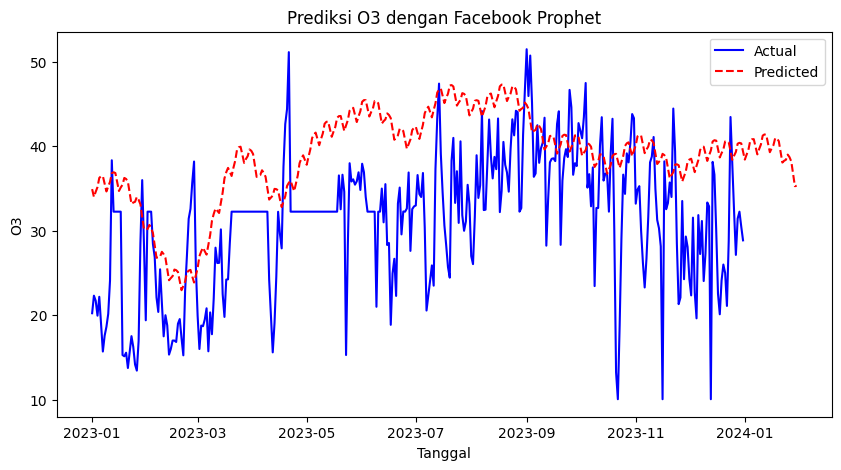

In [75]:
import matplotlib.pyplot as plt

# 9️⃣ Plot hasil prediksi berdasarkan polutan
for pollutant in target_columns:
    plt.figure(figsize=(10, 5))
    
    # Filter hasil prediksi berdasarkan polutan
    df_plot = df_long[df_long["pollutant"] == pollutant]
    
    # Plot data historis
    plt.plot(df_plot["ds"], df_plot["y"], label="Actual", color="blue")
    
    # Plot hasil prediksi
    plt.plot(forecast["ds"], forecast["yhat"], label="Predicted", color="red", linestyle="dashed")
    
    plt.xlabel("Tanggal")
    plt.ylabel(pollutant)
    plt.title(f"Prediksi {pollutant} dengan Facebook Prophet")
    plt.legend()
    plt.show()


In [76]:
# 1️⃣ Ambil hasil prediksi pada test set
df_eval = forecast.merge(df_long, on="ds")  # Gabungkan prediksi dengan data asli

# 2️⃣ Hitung metrik evaluasi untuk setiap polutan
evaluation_results = {}

for pollutant in target_columns:
    # Filter data berdasarkan polutan
    df_eval_pollutant = df_eval[df_eval["pollutant"] == pollutant]
    
    # Ambil nilai aktual dan prediksi
    y_true = df_eval_pollutant["y"].values  # Data asli
    y_pred = df_eval_pollutant["yhat"].values  # Prediksi Prophet
    
    # Hitung metrik evaluasi
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    
    # Simpan hasil evaluasi
    evaluation_results[pollutant] = {"MAE": mae, "MSE": mse, "RMSE": rmse}

# 3️⃣ Tampilkan hasil evaluasi
for pollutant, metrics in evaluation_results.items():
    print(f"\n🔹 Evaluasi Model Prophet untuk {pollutant}:")
    print(f"   MAE  : {metrics['MAE']:.4f}")
    print(f"   MSE  : {metrics['MSE']:.4f}")
    print(f"   RMSE : {metrics['RMSE']:.4f}")


🔹 Evaluasi Model Prophet untuk SO2:
   MAE  : 11.4237
   MSE  : 178.1630
   RMSE : 13.3478

🔹 Evaluasi Model Prophet untuk NO2:
   MAE  : 16.4818
   MSE  : 327.5830
   RMSE : 18.0993

🔹 Evaluasi Model Prophet untuk CO:
   MAE  : 30.1082
   MSE  : 946.5985
   RMSE : 30.7668

🔹 Evaluasi Model Prophet untuk PM 10:
   MAE  : 20.7436
   MSE  : 513.6349
   RMSE : 22.6635

🔹 Evaluasi Model Prophet untuk PM 2.5:
   MAE  : 37.5148
   MSE  : 1572.0358
   RMSE : 39.6489

🔹 Evaluasi Model Prophet untuk O3:
   MAE  : 8.7855
   MSE  : 110.1507
   RMSE : 10.4953


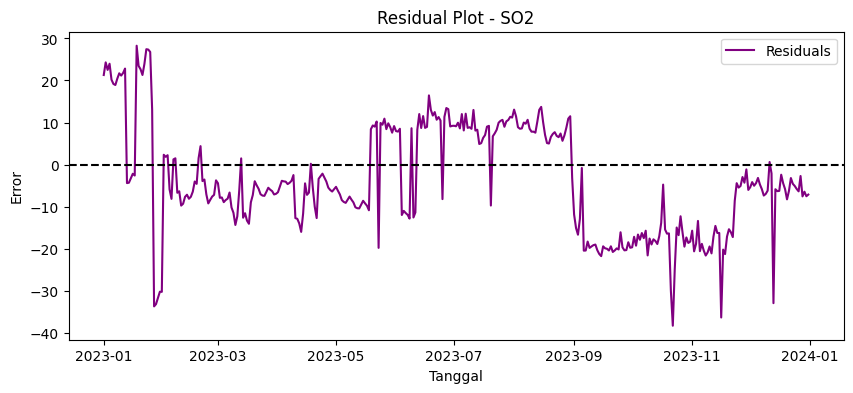

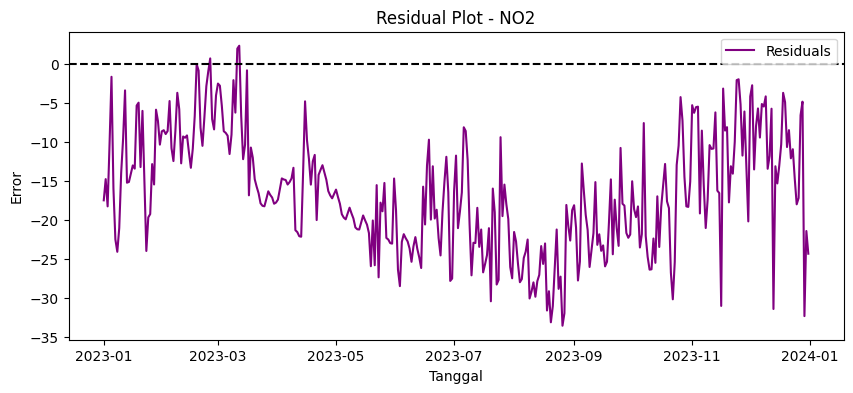

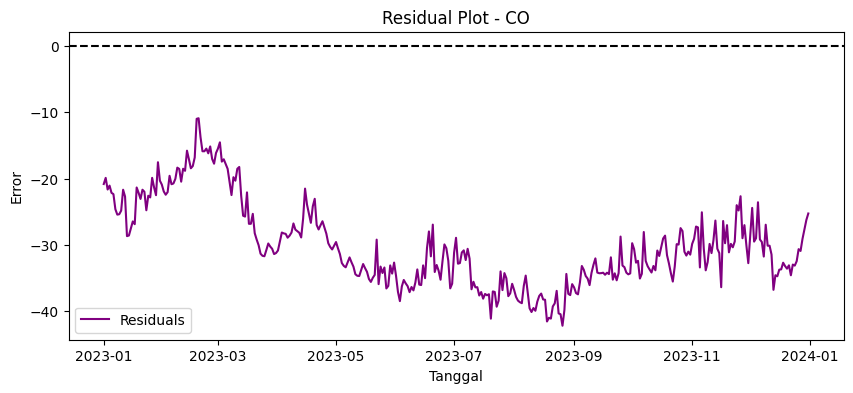

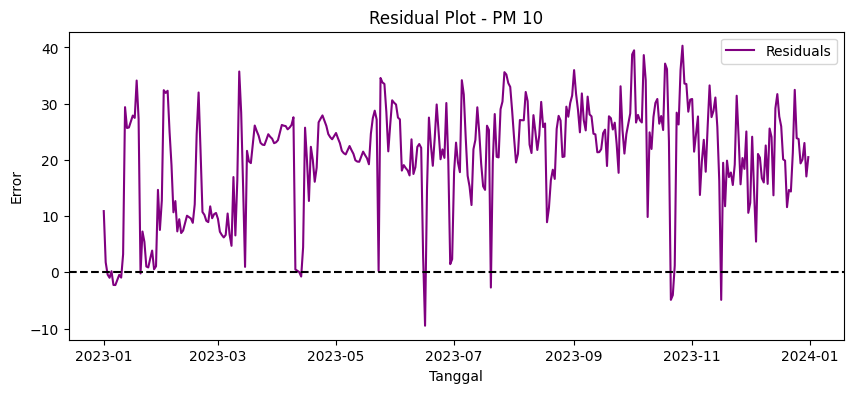

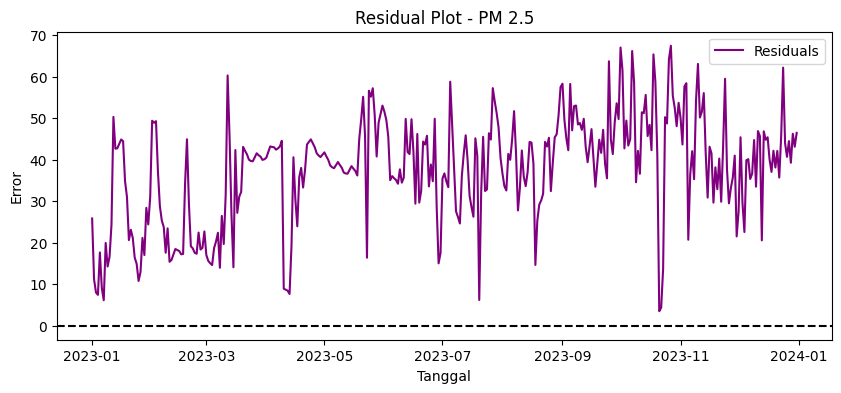

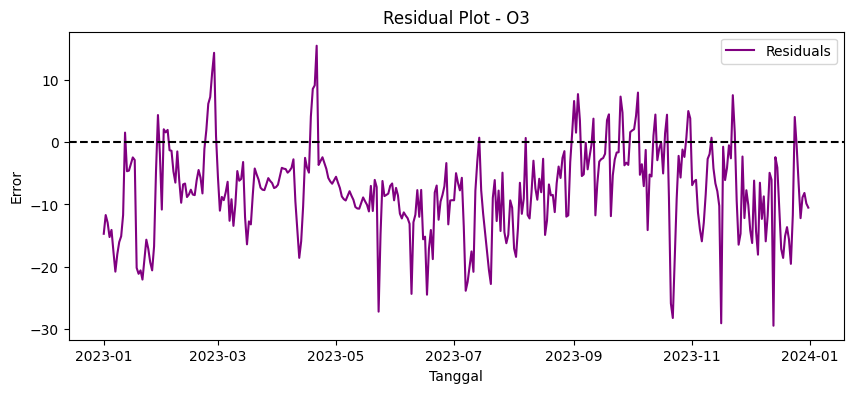

In [77]:
# Residual

# 4️⃣ Plot residuals untuk setiap polutan
for pollutant in target_columns:
    plt.figure(figsize=(10, 4))
    
    # Ambil data residuals (y_true - y_pred)
    df_eval_pollutant = df_eval[df_eval["pollutant"] == pollutant]
    residuals = df_eval_pollutant["y"] - df_eval_pollutant["yhat"]
    
    # Plot residuals
    plt.plot(df_eval_pollutant["ds"], residuals, label="Residuals", color="purple")
    plt.axhline(y=0, color="black", linestyle="--")  # Garis nol untuk referensi
    
    plt.xlabel("Tanggal")
    plt.ylabel("Error")
    plt.title(f"Residual Plot - {pollutant}")
    plt.legend()
    plt.show()


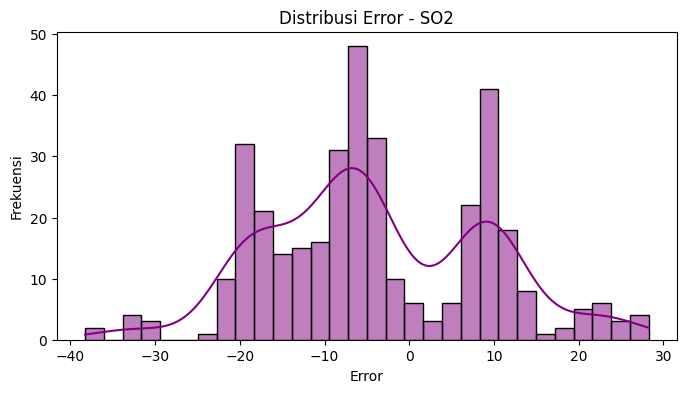

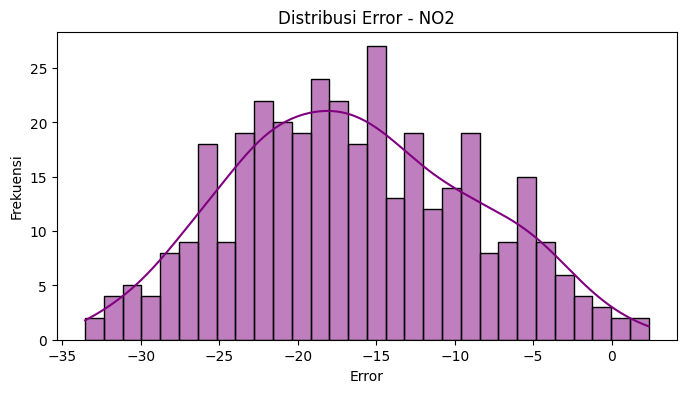

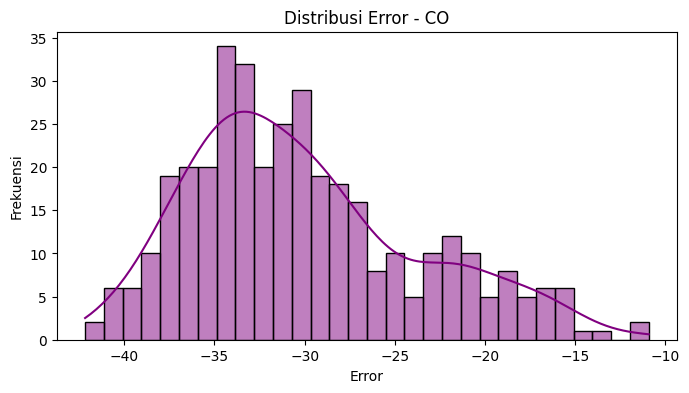

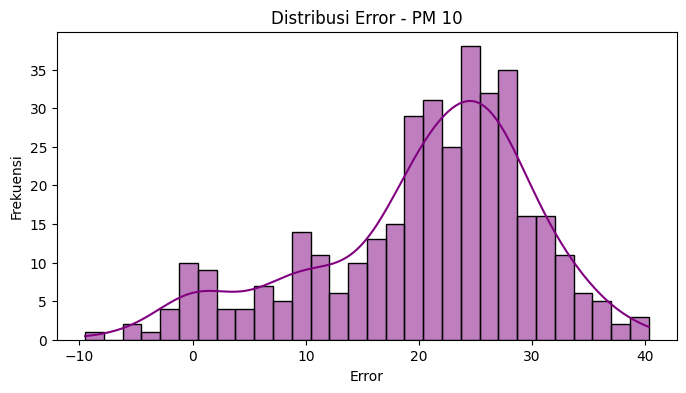

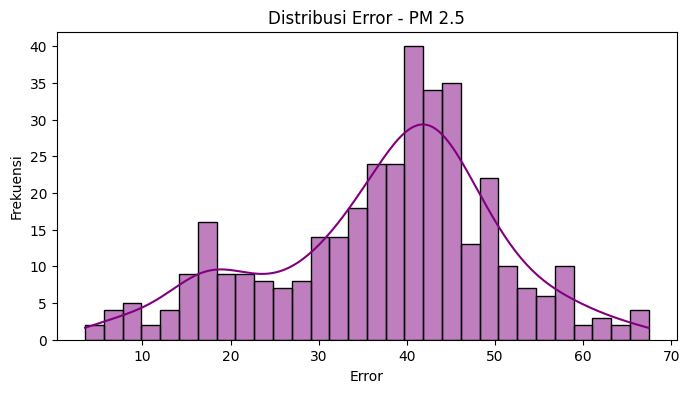

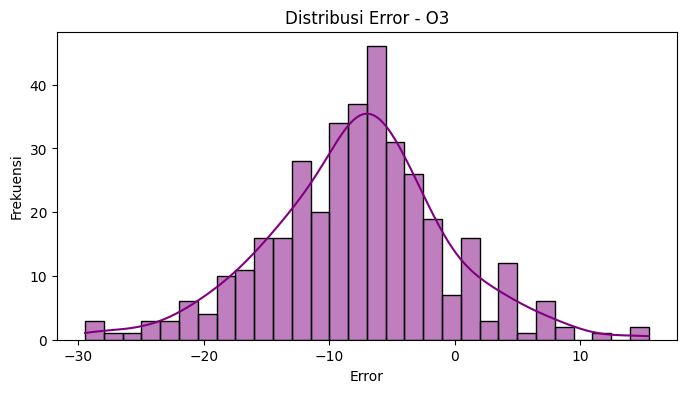

In [78]:
# Eror Distribution

# 5️⃣ Plot distribusi error
for pollutant in target_columns:
    plt.figure(figsize=(8, 4))
    
    df_eval_pollutant = df_eval[df_eval["pollutant"] == pollutant]
    residuals = df_eval_pollutant["y"] - df_eval_pollutant["yhat"]
    
    sns.histplot(residuals, bins=30, kde=True, color="purple")
    
    plt.xlabel("Error")
    plt.ylabel("Frekuensi")
    plt.title(f"Distribusi Error - {pollutant}")
    plt.show()